In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (confusion_matrix, accuracy_score, classification_report, precision_score,
                             recall_score, f1_score, roc_curve, auc, ConfusionMatrixDisplay)
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import GridSearchCV
from sklearn.naive_bayes import GaussianNB, ComplementNB, MultinomialNB
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Classification

## First Target (Binary Class Classification): isMovie

### Retrieving the clean and scaled datasets (train and test) from the Data Understanding step

In [2]:
# Load the preprocessed data
data_train = pd.read_csv('data/output/02_data_understanding/clean_normalized_data_train.csv')
data_test = pd.read_csv('data/output/02_data_understanding/clean_normalized_data_test.csv')

data_train.info()
data_train.head(10)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14278 entries, 0 to 14277
Columns: 204 entries, originalTitle to ZW
dtypes: float64(7), int64(196), object(1)
memory usage: 22.2+ MB


,originalTitle,rating,startYear,runtimeMinutes,numVotes,totalCredits,criticReviewsTotal,titleType,isAdult,numRegions,...,VC,VE,VN,XKV,XWG,XYU,YUCS,ZA,ZM,ZW
0,Neogenic Nightmare Chapter 3: Hydro-Man,8,1995,-0.155631,1.744420,-0.461830,0.364799,2,0,-0.664249,...,0,0,0,0,0,0,0,0,0,0
1,Idealnaya para,6,1992,0.876931,-0.198722,-0.331178,-0.523955,0,0,-0.664249,...,0,0,0,0,0,0,0,0,0,0
2,MasterChef Celebrity México,6,2021,-0.517719,-0.776639,0.511167,-0.523955,5,0,-0.664249,...,0,0,0,0,0,0,0,0,0,0
3,"Kiss, Kiss Bang, Bang",8,1995,-0.006605,0.392283,1.192339,-0.523955,2,0,-0.664249,...,0,0,0,0,0,0,0,0,0,0
4,Nanba MG5,8,2022,0.358912,0.189888,0.721140,-0.523955,3,0,2.389198,...,0,0,0,0,0,0,0,0,0,0
5,Estrela de Oito Pontas,8,1996,-1.643205,-0.911322,-2.498186,-0.523955,1,0,-0.664249,...,0,0,0,0,0,0,0,0,0,0
6,Ulot Puran,9,2022,0.358912,-0.413652,-0.787304,-0.523955,3,0,-0.664249,...,0,0,0,0,0,0,0,0,0,0
7,JJBA Mangabridged: Phantom Blood 2 of 2,9,2017,-0.035070,-0.287715,-1.789757,-0.523955,4,0,-0.664249,...,0,0,0,0,0,0,0,0,0,0
8,1979 AFC Championship Game,9,1980,0.358912,-1.081501,0.706434,-0.523955,7,0,-0.664249,...,0,0,0,0,0,0,0,0,0,0
9,Golubaya chashka,7,1965,0.358912,-0.487161,0.069507,-0.523955,0,0,0.386168,...,0,0,0,0,0,0,0,0,0,0


In [3]:
# Creation of the new columns isMovie, that will be used as target
data_train['isMovie'] = (data_train['titleType'] == 0).astype(int)
data_test['isMovie'] = (data_test['titleType'] == 0).astype(int)

selected_columns = ['runtimeMinutes', 'numVotes', 'rating', 'totalCredits', 'totalMedia', 'criticReviewsTotal', 'isMovie',
                    'isAdult', 'numRegions', 'NumberOfCountryoforigin', 'totalRecognitions', 'NumberOfGenres',
                    'startYearDecade', 'startYear']

df_selected = data_train[selected_columns]

# Step 3: Calculate the correlation of 'isMovie' with each of the selected columns
correlation_isMovie = df_selected.corr()['isMovie'].drop('isMovie')  # Dropping 'isMovie' from the result

# Step 6: Print correlation values (optional)
print(correlation_isMovie)

runtimeMinutes             0.621105
numVotes                   0.230742
rating                    -0.313648
totalCredits               0.074765
totalMedia                 0.298275
criticReviewsTotal         0.377485
isAdult                   -0.022922
numRegions                 0.448651
NumberOfCountryoforigin    0.127286
totalRecognitions          0.221147
NumberOfGenres            -0.149885
startYearDecade           -0.170844
startYear                 -0.174255
Name: isMovie, dtype: float64


Percentage distribution of 'isMovie' (combined train and test):
isMovie
0    66.259438
1    33.740562
Name: proportion, dtype: float64


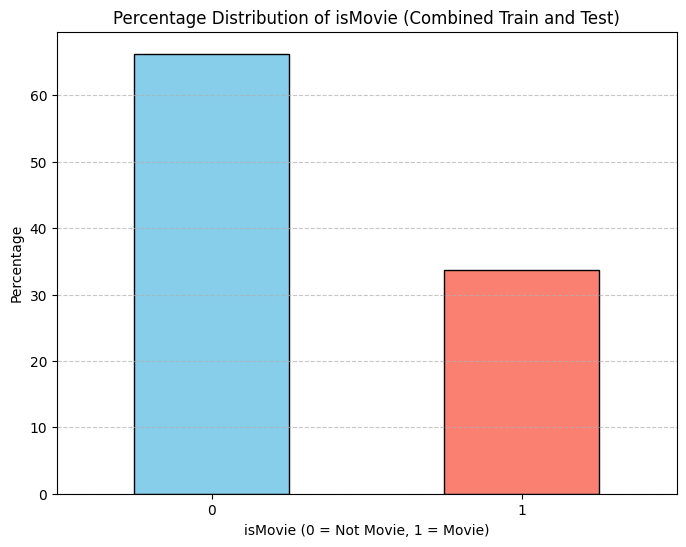

In [4]:
# Combine train and test datasets for analysis
combined_data = pd.concat([data_train, data_test])

# Calculate the percentage distribution of 'isMovie'
percentages_combined = combined_data['isMovie'].value_counts(normalize=True) * 100

# Print the percentages
print("Percentage distribution of 'isMovie' (combined train and test):")
print(percentages_combined)

plt.figure(figsize=(8, 6))
percentages_combined.plot(kind='bar', color=['skyblue', 'salmon'], edgecolor='black')
plt.title('Percentage Distribution of isMovie (Combined Train and Test)')
plt.xlabel('isMovie (0 = Not Movie, 1 = Movie)')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## KNN

In [5]:
# List of columns to include for k-NN
# After a research, this selection of columns provided the best result
selected_columns = [
    'startYear', 'runtimeMinutes', 'numVotes', 'totalCredits',
    'criticReviewsTotal', 'isAdult', 'numRegions'
]

# Define features and target
X_train_knn = data_train[selected_columns]
y_train_knn = data_train['isMovie']

X_test_knn = data_test[selected_columns]
y_test_knn = data_test['isMovie']

X_train_knn.head()

,startYear,runtimeMinutes,numVotes,totalCredits,criticReviewsTotal,isAdult,numRegions
0,1995,-0.155631,1.744420,-0.461830,0.364799,0,-0.664249
1,1992,0.876931,-0.198722,-0.331178,-0.523955,0,-0.664249
2,2021,-0.517719,-0.776639,0.511167,-0.523955,0,-0.664249
3,1995,-0.006605,0.392283,1.192339,-0.523955,0,-0.664249
4,2022,0.358912,0.189888,0.721140,-0.523955,0,2.389198


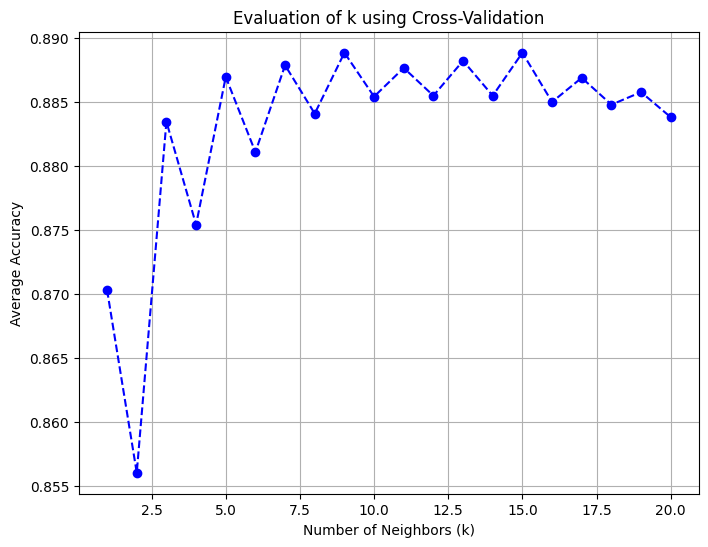

In [6]:
# Search for the best k value
k_values = range(1, 21)
cv_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_knn, y_train_knn, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())

# Plot to visualize k search
plt.figure(figsize=(8, 6))
plt.plot(k_values, cv_scores, marker='o', linestyle='--', color='b')
plt.title('Evaluation of k using Cross-Validation')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Average Accuracy')
plt.grid()
plt.show()

In [7]:
# Best k value
best_k = k_values[np.argmax(cv_scores)]
print(f"Best k value: {best_k}")

Best k value: 15


In [8]:
# Train the model with the best k
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train_knn, y_train_knn)

y_pred = knn.predict(X_test_knn)

# Evaluate performance metrics
accuracy = accuracy_score(y_test_knn, y_pred)
precision = precision_score(y_test_knn, y_pred)
recall = recall_score(y_test_knn, y_pred)
f1 = f1_score(y_test_knn, y_pred)

print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

Accuracy: 0.89
Precision: 0.83
Recall: 0.86
F1 Score: 0.84


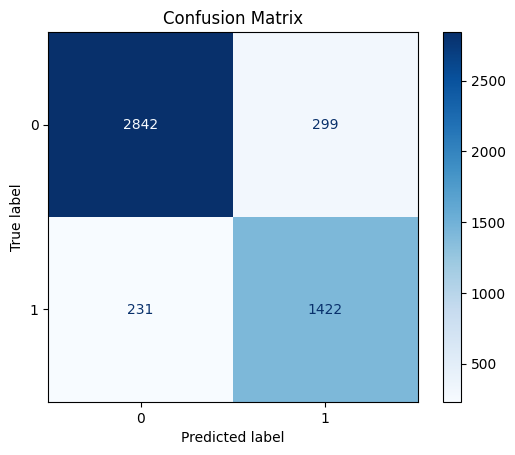

In [9]:
# Confusion matrix
cm = confusion_matrix(y_test_knn, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=knn.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

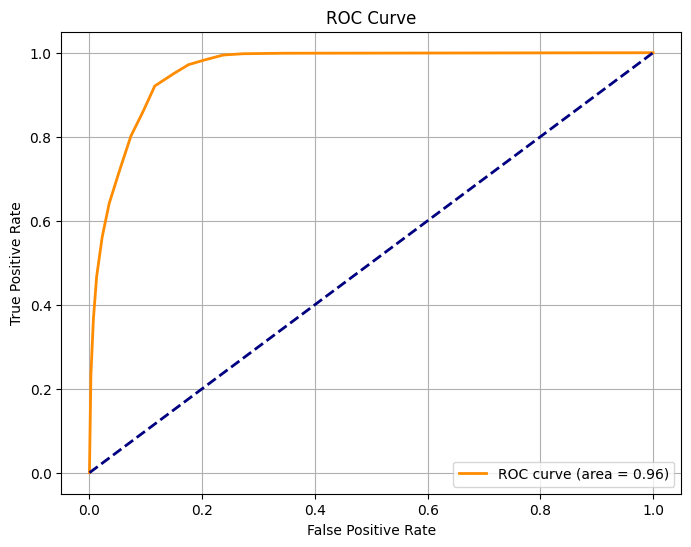

In [10]:
# ROC curve
y_test_binarized = label_binarize(y_test_knn, classes=[0, 1])
y_pred_proba = knn.predict_proba(X_test_knn)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test_binarized, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.grid()
plt.show()

## Naive Bayes

### We'll use the Gaussian Naive Bayes Classifier, as the columns have been normalized.

In [11]:
# List of columns to include for Gaussian Naive Bayes
# After a research, this selection of columns provided the best result
selected_columns = [
    'rating', 'runtimeMinutes', 'isAdult', 'totalCredits'
]

# Define features and target
X_train_gnb = data_train[selected_columns]
y_train_gnb = data_train['isMovie']

X_test_gnb = data_test[selected_columns]
y_test_gnb = data_test['isMovie']

In [12]:
# after having tried with Gaussian, Complement and Multinomial, Gaussian gave the best results
gnb = GaussianNB()
gnb.fit(X_train_gnb, y_train_gnb)

# Make predictions on the test set
y_pred = gnb.predict(X_test_gnb)

accuracy = accuracy_score(y_test_gnb, y_pred)
print(f"Accuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test_gnb, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test_gnb, y_pred)
print("\nConfusion Matrix:")
print(cm)

Accuracy: 0.8934

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.89      0.92      3141
           1       0.81      0.89      0.85      1653

    accuracy                           0.89      4794
   macro avg       0.88      0.89      0.88      4794
weighted avg       0.90      0.89      0.89      4794


Confusion Matrix:
[[2805  336]
 [ 175 1478]]


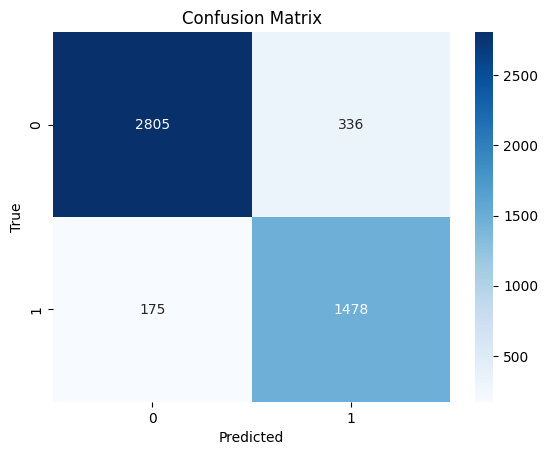

In [13]:
# Visualize Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=gnb.classes_, yticklabels=gnb.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

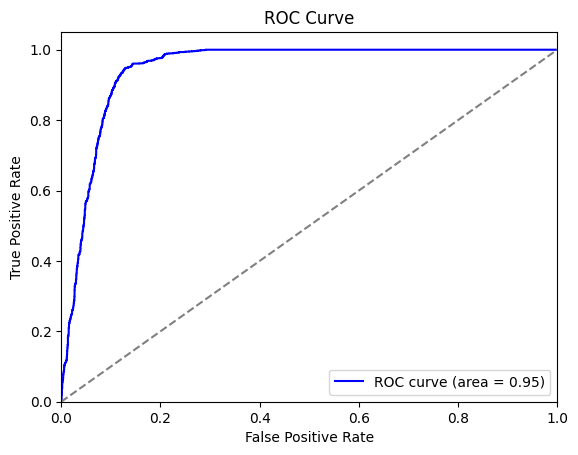

In [14]:
# ROC Curve
# Calculate False Positive Rate and True Positive Rate
fpr, tpr, thresholds = roc_curve(y_test_gnb, gnb.predict_proba(X_test_gnb)[:, 1])
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure()
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Diagonal line for random classifier
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

## Decision Trees

In [15]:
# For Decision Trees, we'll use the not normalized datasets
not_normalized_data_train = pd.read_csv('data/output/02_data_understanding/clean_data_train.csv')
not_normalized_data_test = pd.read_csv('data/output/02_data_understanding/clean_data_test.csv')

# Creation of the new columns isMovie, that will be used as target
not_normalized_data_train['isMovie'] = (not_normalized_data_train['titleType'] == 0).astype(int)
not_normalized_data_test['isMovie'] = (not_normalized_data_test['titleType'] == 0).astype(int)

# Define features and target
X_train_dt = not_normalized_data_train.drop(columns=['originalTitle', 'titleType', 'isMovie'])
y_train_dt = not_normalized_data_train['isMovie']

X_test_dt = not_normalized_data_test.drop(columns=['originalTitle', 'titleType', 'isMovie'])
y_test_dt = not_normalized_data_test['isMovie']

# Base model
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_dt, y_train_dt)

# Predictions
y_pred = dt.predict(X_test_dt)

# Score
print("Accuracy:", accuracy_score(y_test_dt, y_pred))
print("Classification Report:\n", classification_report(y_test_dt, y_pred)) 

Accuracy: 0.9203170629954109
Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.94      0.94      3141
           1       0.88      0.89      0.89      1653

    accuracy                           0.92      4794
   macro avg       0.91      0.91      0.91      4794
weighted avg       0.92      0.92      0.92      4794



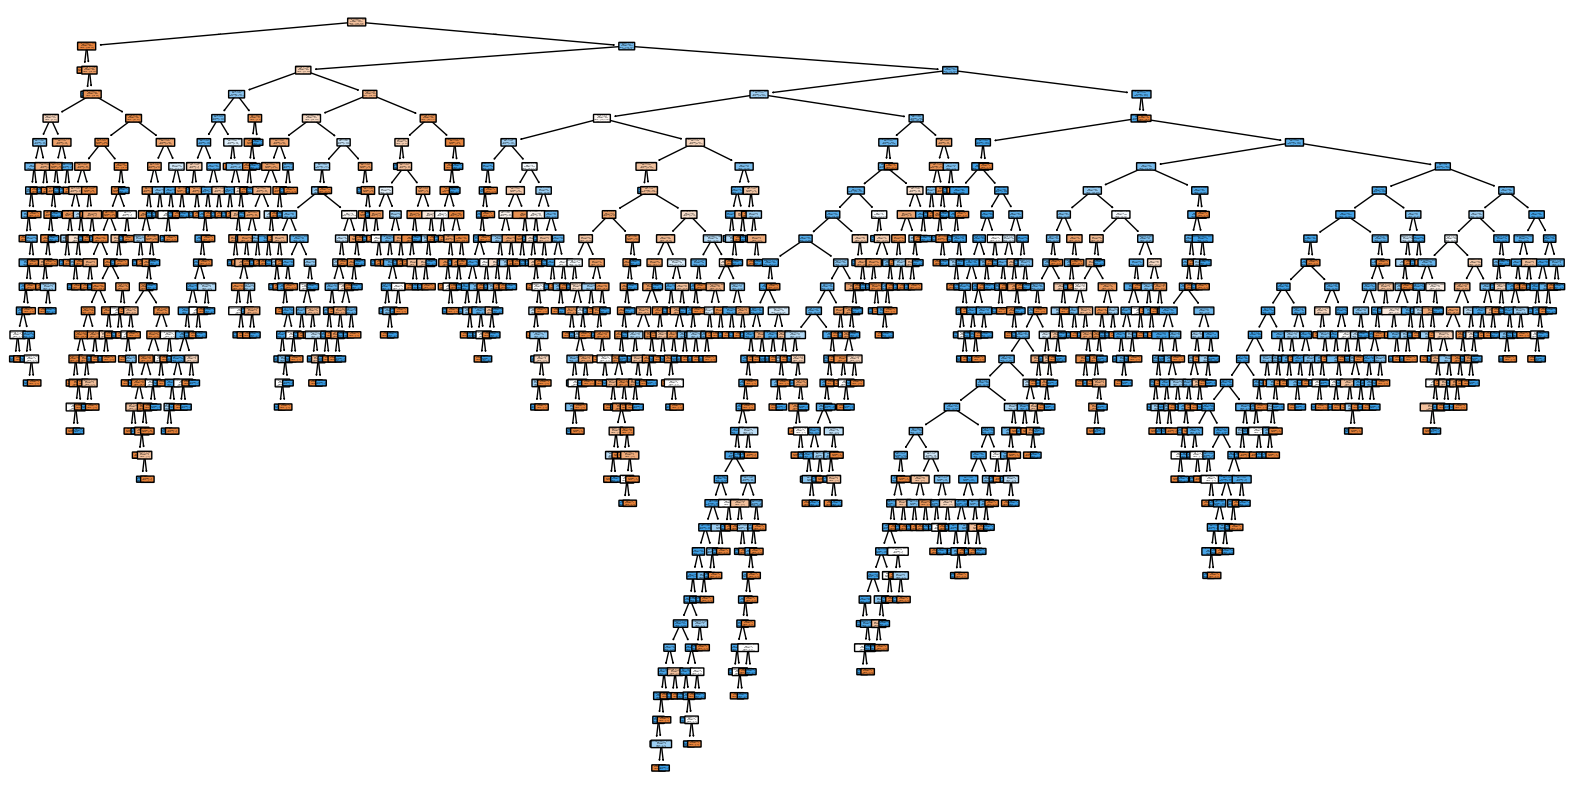

In [16]:
plt.figure(figsize=(20, 10))
plot_tree(dt, feature_names=X_train_dt.columns, class_names=['Not Movie', 'Movie'], filled=True, rounded=True)
plt.show()

In [17]:
# Hyperparameters
param_grid = {
    'criterion': ['gini', 'entropy'],         # Funzione di split
    'max_depth': [3, 5, 10, None],            # Profondità massima
    'min_samples_split': [2, 5, 10],          # Split minimo
    'min_samples_leaf': [1, 2, 4],            # Foglie minime
}

grid_search = GridSearchCV(estimator=DecisionTreeClassifier(random_state=42),
                           param_grid=param_grid,
                           cv=5,
                           scoring='accuracy',
                           verbose=1)

grid_search.fit(X_train_dt, y_train_dt)

# Migliori parametri e valutazione
best_params = grid_search.best_params_
print("Best Parameters:", best_params)

best_dt = grid_search.best_estimator_
y_pred_best = best_dt.predict(X_test_dt)

print("Optimized Accuracy:", accuracy_score(y_test_dt, y_pred_best))


Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best Parameters: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10}
Optimized Accuracy: 0.9257405089695453


Optimized Accuracy: 0.92636629119733
Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.93      0.94      3141
           1       0.88      0.91      0.90      1653

    accuracy                           0.93      4794
   macro avg       0.92      0.92      0.92      4794
weighted avg       0.93      0.93      0.93      4794



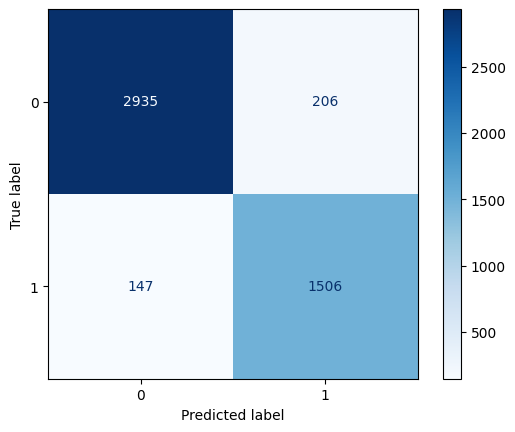

In [18]:
# Define the Decision Tree model with optimized parameters
dt_optimized = DecisionTreeClassifier(
    criterion='entropy',           # Split criterion (information gain)
    max_depth=10,                  # Maximum depth of the tree
    min_samples_leaf=4,            # Minimum number of samples required for a leaf node
    min_samples_split=2,           # Minimum number of samples required to split a node
    random_state=42                # Ensures reproducibility of results
)

# Train the model on the training dataset
dt_optimized.fit(X_train_dt, y_train_dt)

# Make predictions on the test dataset
y_pred_optimized = dt_optimized.predict(X_test_dt)

# Evaluate the model's performance
print("Optimized Accuracy:", accuracy_score(y_test_dt, y_pred_optimized))  # Output overall accuracy
print("Classification Report:\n", classification_report(y_test_dt, y_pred_optimized))  # Detailed metrics

# Generate the confusion matrix
conf_matrix = confusion_matrix(y_test_dt, y_pred_optimized)

# Display the confusion matrix as a heatmap
ConfusionMatrixDisplay(conf_matrix, display_labels=dt_optimized.classes_).plot(cmap="Blues")

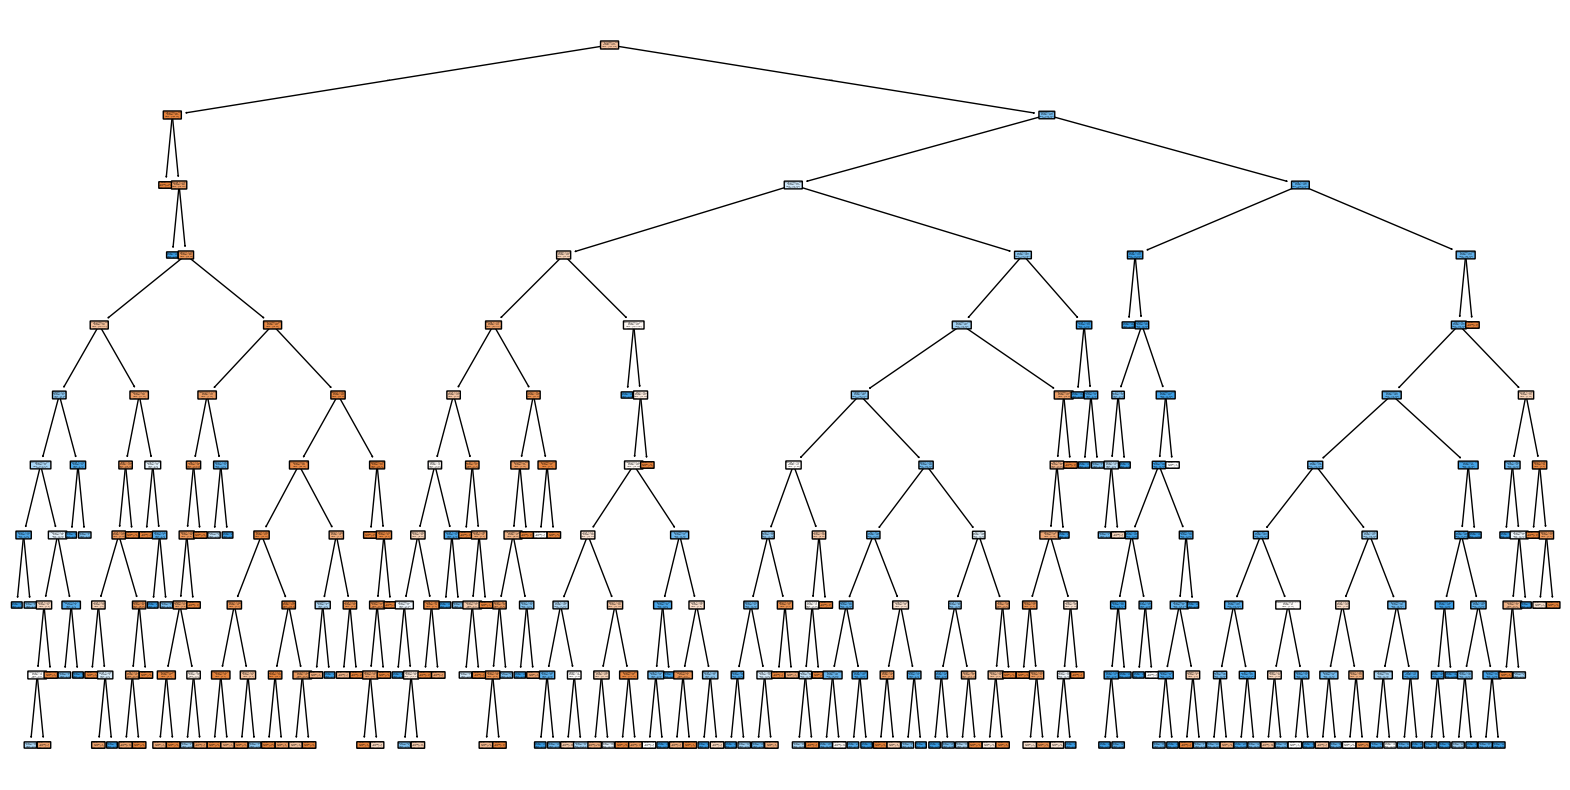

In [19]:
plt.figure(figsize=(20, 10))
plot_tree(dt_optimized, feature_names=X_train_dt.columns, class_names=['Not Movie', 'Movie'], filled=True, rounded=True)
plt.show()